## Tiny SQL Development  

### Set up

In [ ]:
%%bash
sudo apt-get update
sudo apt-get install -y gettext-base

#### Install depdenence Library

In [ ]:
!pip install -q sqlglot pyyaml datasets seaborn python-dotenv sqlalchemy>=2.0 pyyaml --extra-index-url https://pypi.org/simple   --no-warn-script-location

#### Import Libraries

In [ ]:
import os
import sys
import dotenv
import json
import logging
import sqlglot
import random
import yaml
import copy
import warnings

warnings.filterwarnings("ignore")

In [ ]:


project_dir=f'/content/aai-590-tinysql'
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)
    sys.path.insert(1, f"{project_dir}/src")

os.environ['PROJECT_DIR'] = project_dir

if os.path.exists(f'{project_dir}/env.txt'):
    dotenv.load_dotenv(f"{project_dir}/env.txt")
else:
    print("Env file does not exist.")

In [ ]:
from datasets import load_dataset
from huggingface_hub import login

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from collections import Counter

from utils.config_loader import config_loader

logging.getLogger("datasets").setLevel(logging.ERROR)
logging.getLogger("sqlglot").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

### Data Ingestion

In [ ]:
hf_token=os.getenv("HF_TOKEN")

In [ ]:
# Explicitly log in to Hugging Face Hub
login(token=hf_token)

In [ ]:
ds = load_dataset("gretelai/synthetic_text_to_sql", split="train")
raw_subset = ds.select(range(100000))

In [ ]:
test_ds = load_dataset("gretelai/synthetic_text_to_sql", split="test")
tinycode_test_ds = test_ds.select(range(5000))
print (tinycode_test_ds[0])


{'id': 1, 'domain': 'artificial intelligence', 'domain_description': 'AI data on algorithmic fairness, AI safety, explainable AI, and creative AI applications.', 'sql_complexity': 'basic SQL', 'sql_complexity_description': 'basic SQL with a simple select statement', 'sql_task_type': 'analytics and reporting', 'sql_task_type_description': 'generating reports, dashboards, and analytical insights', 'sql_prompt': "What is the average explainability score of creative AI applications in 'Europe' and 'North America' in the 'creative_ai' table?", 'sql_context': "CREATE TABLE creative_ai (application_id INT, name TEXT, region TEXT, explainability_score FLOAT); INSERT INTO creative_ai (application_id, name, region, explainability_score) VALUES (1, 'ApplicationX', 'Europe', 0.87), (2, 'ApplicationY', 'North America', 0.91), (3, 'ApplicationZ', 'Europe', 0.84), (4, 'ApplicationAA', 'North America', 0.93), (5, 'ApplicationAB', 'Europe', 0.89);", 'sql': "SELECT AVG(explainability_score) FROM creativ

### Preprocessing & Visualizations

In [ ]:
def apply_tinycode_logic(example):
    original_sql = example['sql']
    schema = example['sql_context']
    question = example['sql_prompt']
    explanation = example['sql_explanation']

    # --- LAYER 1 & 3: Dialect Transpilation & BQ Normalization ---
    try:
        # Transpile to BigQuery and force backticks (identify=True)
        bq_sql = sqlglot.transpile(original_sql, read=None, write="bigquery", identify=True)[0]

        # BQ Normalization: SAFE_CAST and QUALIFY
        # (Example: replace risky CASTs with SAFE_CAST)
        bq_sql = bq_sql.replace("CAST(", "SAFE_CAST(").replace("cast(", "safe_cast(")
    except:
        bq_sql = original_sql

    # --- LAYER 2: Schema Pruning (Negative Sampling) ---
    # In 20% of cases, we add a "distractor" table to the schema
    if random.random() < 0.20:
        distractor = "\nCREATE TABLE `irrelevant_metadata` (id INT64, log_date DATE, notes STRING);"
        schema = schema + distractor

    # --- LAYER 4: Sample Row Injection (Value Grounding) ---
    # We simulate sample rows to help the model understand data values
    # In a real project, you'd pull these from the DB. Here we inject a hint.
    grounding_hint = "\n-- Sample Rows: If filtering by status, values are usually ['ACTIVE', 'PENDING', 'CLOSED']."
    schema = schema + grounding_hint

    # --- LAYER 5: Multi-style Augmentation ---
    # Randomly prefix questions to simulate different user styles
    styles = [
        "", # Standard
        "Hey, can you ",
        "Write a BigQuery script to ",
        "Using GoogleSQL, ",
        "Query the database for: "
    ]
    augmented_question = random.choice(styles) + question

    # --- FINAL FORMATTING: Gemma 3 Chat Template ---
    formatted_text = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery Developer. Follow GoogleSQL best practices including backticks and SAFE functions.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### CONTEXTUAL SCHEMA:
{schema}

### USER REQUEST:
{augmented_question}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
<think>
{explanation}
</think>
```sql
{bq_sql}
```<|eot_id|>"""

    return {"text": formatted_text}

# Apply all logic
tinycode_train_ds = raw_subset.map(apply_tinycode_logic, remove_columns=raw_subset.column_names)

# Verify the first record
print(tinycode_train_ds[0]['text'])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery Developer. Follow GoogleSQL best practices including backticks and SAFE functions.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### CONTEXTUAL SCHEMA:
CREATE TABLE salesperson (salesperson_id INT, name TEXT, region TEXT); INSERT INTO salesperson (salesperson_id, name, region) VALUES (1, 'John Doe', 'North'), (2, 'Jane Smith', 'South'); CREATE TABLE timber_sales (sales_id INT, salesperson_id INT, volume REAL, sale_date DATE); INSERT INTO timber_sales (sales_id, salesperson_id, volume, sale_date) VALUES (1, 1, 120, '2021-01-01'), (2, 1, 150, '2021-02-01'), (3, 2, 180, '2021-01-01');
-- Sample Rows: If filtering by status, values are usually ['ACTIVE', 'PENDING', 'CLOSED'].

### USER REQUEST:
What is the total volume of timber sold by each salesperson, sorted by salesperson?
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
<think>
Joins timber_sales and salesperson tables, groups sales by s

/tmp/ipython-input-121/1063042645.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='sql_task_type', order=task_order, palette='viridis')
/tmp/ipython-input-121/1063042645.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kw_df.head(10), x='Frequency', y='Keyword', palette='magma')


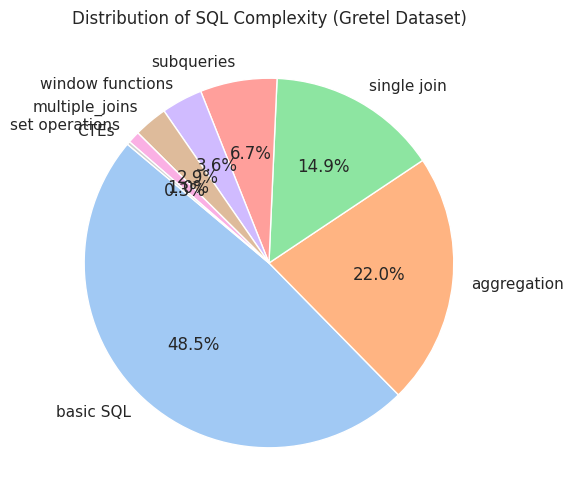

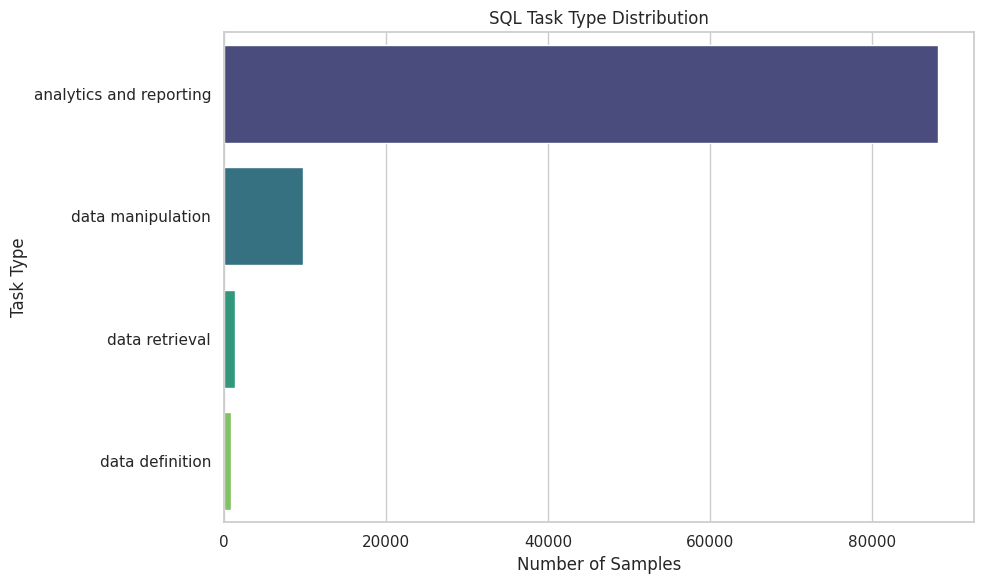

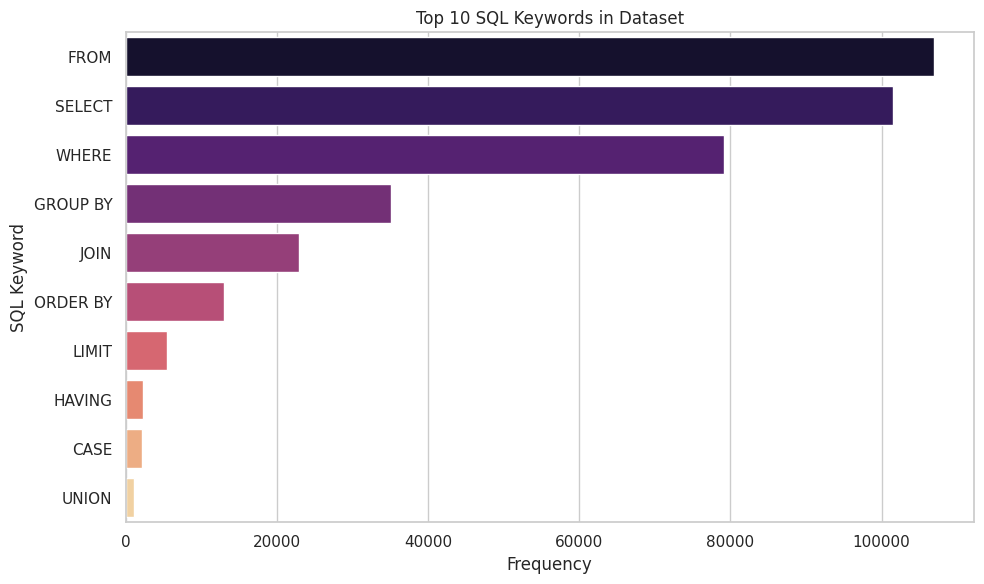

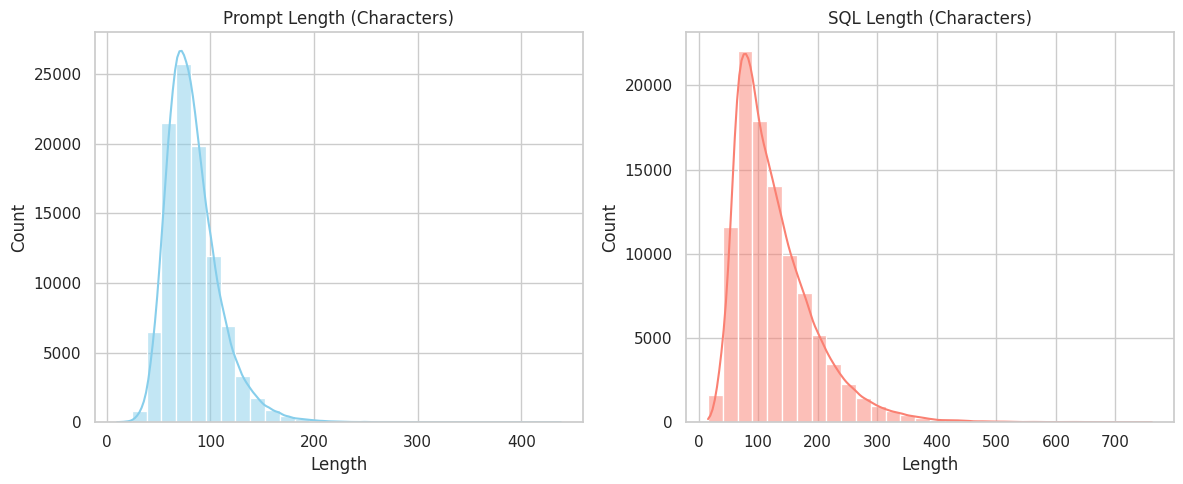

In [ ]:
# Assuming 'train_data' is your dataset object from:
# train_data = load_dataset("gretelai/synthetic_text_to_sql", split="train").select(range(10000))
# Create DataFrame from raw_subset to retain original columns for analysis
df = raw_subset.to_pandas()

# Set the visualization style
sns.set_theme(style="whitegrid")

# 1. SQL Complexity Distribution
plt.figure(figsize=(8, 6))
df['sql_complexity'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=140
)
plt.title('Distribution of SQL Complexity (Gretel Dataset)')
plt.ylabel('')
plt.savefig('sql_complexity_pie.png')

# 2. SQL Task Type Distribution
plt.figure(figsize=(10, 6))
task_order = df['sql_task_type'].value_counts().index
sns.countplot(data=df, y='sql_task_type', order=task_order, palette='viridis')
plt.title('SQL Task Type Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Task Type')
plt.tight_layout()
plt.savefig('task_type_bar.png')

# 3. SQL Keyword Frequency (Top 10)
def get_keywords(sql_list):
    keywords = []
    for sql in sql_list:
        # Regex to find major SQL keywords
        found = re.findall(r'\b(SELECT|FROM|JOIN|WHERE|GROUP BY|ORDER BY|LIMIT|CASE|CAST|UNION|WITH|HAVING)\b', sql.upper())
        keywords.extend(found)
    return Counter(keywords)

kw_counts = get_keywords(df['sql'].tolist())
kw_df = pd.DataFrame(kw_counts.items(), columns=['Keyword', 'Frequency']).sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=kw_df.head(10), x='Frequency', y='Keyword', palette='magma')
plt.title('Top 10 SQL Keywords in Dataset')
plt.xlabel('Frequency')
plt.ylabel('SQL Keyword')
plt.tight_layout()
plt.savefig('keyword_frequency.png')

# 4. Prompt vs SQL Length Distribution
df['prompt_len'] = df['sql_prompt'].apply(len)
df['sql_len'] = df['sql'].apply(len)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['prompt_len'], bins=30, color='skyblue', kde=True)
plt.title('Prompt Length (Characters)')
plt.xlabel('Length')

plt.subplot(1, 2, 2)
sns.histplot(df['sql_len'], bins=30, color='salmon', kde=True)
plt.title('SQL Length (Characters)')
plt.xlabel('Length')

plt.tight_layout()
plt.savefig('length_distribution.png')

# Show all plots
plt.show()

##### 5. Prompt Length vs. SQL Length

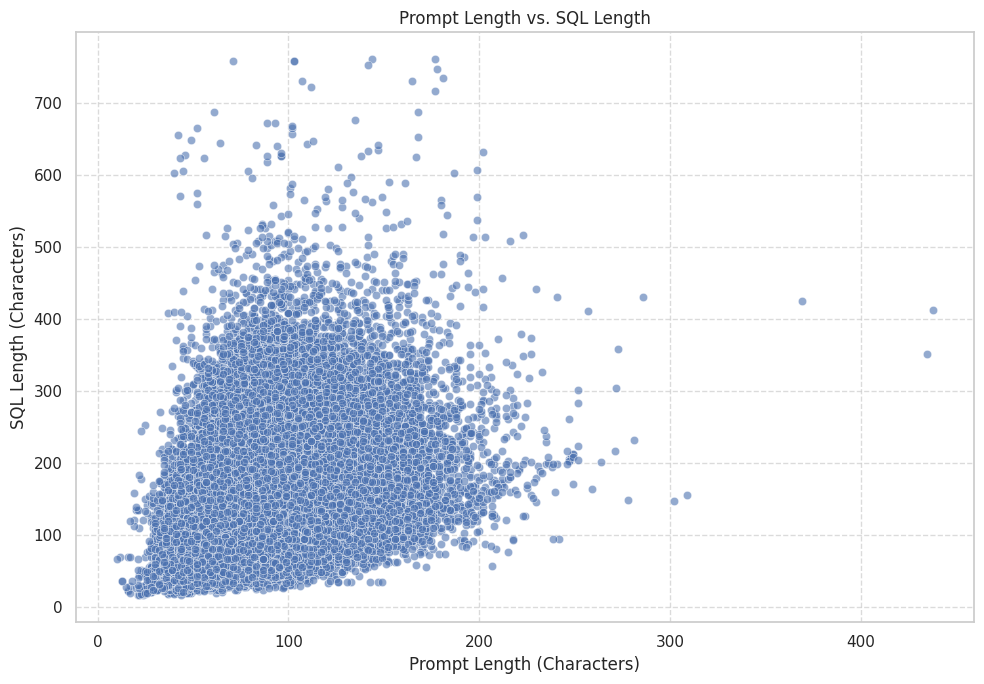

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='prompt_len', y='sql_len', alpha=0.6)
plt.title('Prompt Length vs. SQL Length')
plt.xlabel('Prompt Length (Characters)')
plt.ylabel('SQL Length (Characters)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('prompt_sql_length_scatter.png')
plt.show()

##### 6. Distribution of Top 10 Domains

/tmp/ipython-input-121/1761744423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='domain', order=domain_order, palette='cividis')


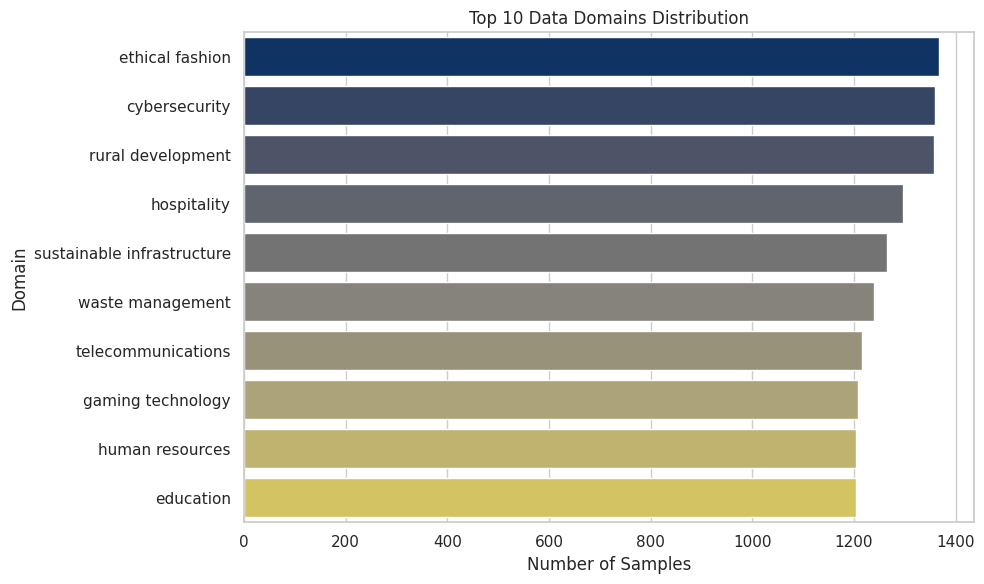

In [ ]:
plt.figure(figsize=(10, 6))
domain_order = df['domain'].value_counts().head(10).index
sns.countplot(data=df, y='domain', order=domain_order, palette='cividis')
plt.title('Top 10 Data Domains Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Domain')
plt.tight_layout()
plt.savefig('domain_distribution_bar.png')
plt.show()

##### 7. SQL Complexity by SQL Task Type

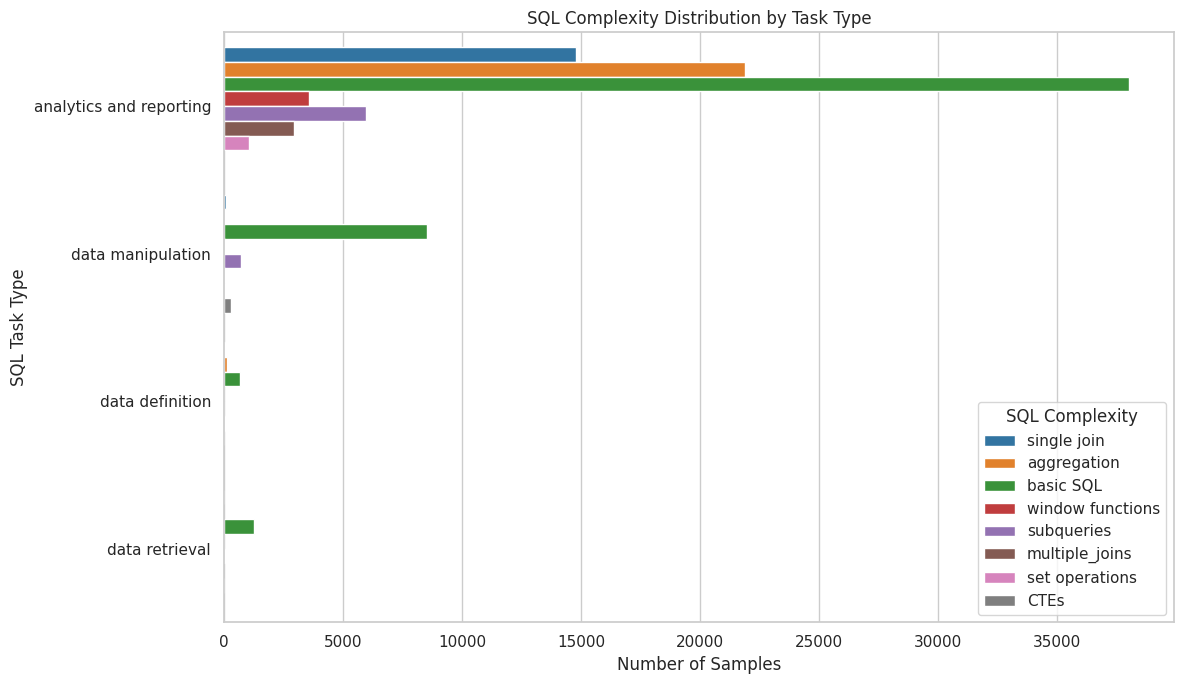

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='sql_task_type', hue='sql_complexity', palette='tab10', dodge=True)
plt.title('SQL Complexity Distribution by Task Type')
plt.xlabel('Number of Samples')
plt.ylabel('SQL Task Type')
plt.legend(title='SQL Complexity')
plt.tight_layout()
plt.savefig('complexity_by_task_type_bar.png')
plt.show()

In [ ]:
import re

def extract_joined_tables(sql_query):
    # Convert query to uppercase for case-insensitive matching
    sql_query_upper = sql_query.upper()

    # Regex to find table names after FROM or JOIN
    # It looks for 'FROM ' or 'JOIN ' followed by a word character sequence (the table name)
    # and stops before the next space, punctuation, or keyword. It also handles aliases.
    # Pattern to capture table name which might be followed by AS alias or just alias
    from_pattern = r"FROM\s+`?([A-Z0-9_]+)`?(?:\s+AS)?(?:\s+[A-Z0-9_]+)?"
    join_pattern = r"JOIN\s+`?([A-Z0-9_]+)`?(?:\s+AS)?(?:\s+[A-Z0-9_]+)?"

    from_tables = re.findall(from_pattern, sql_query_upper)
    join_tables = re.findall(join_pattern, sql_query_upper)

    # Combine and get unique table names
    all_tables = list(set(from_tables + join_tables))

    return all_tables

# Apply the function to the 'sql' column and create a new column 'joined_tables'
df['joined_tables'] = df['sql'].apply(extract_joined_tables)

# Display the first few rows with the new column
print(df[['sql', 'joined_tables']].head())

                                                 sql  \
0  SELECT salesperson_id, name, SUM(volume) as to...   
1  SELECT equipment_type, SUM(maintenance_frequen...   
2  SELECT COUNT(*) FROM marine_species WHERE loca...   
3  SELECT trader_id, stock, SUM(price * quantity)...   
4  SELECT type, cost FROM (SELECT type, cost, ROW...   

                 joined_tables  
0  [SALESPERSON, TIMBER_SALES]  
1      [EQUIPMENT_MAINTENANCE]  
2             [MARINE_SPECIES]  
3              [TRADE_HISTORY]  
4                   [UPGRADES]  


In [ ]:
from collections import Counter
import pandas as pd

# Flatten the list of lists in the 'joined_tables' column
all_joined_tables = [table for sublist in df['joined_tables'] for table in sublist]

# Count the frequency of each table
table_counts = Counter(all_joined_tables)

# Convert to DataFrame for easier handling and plotting
table_counts_df = pd.DataFrame(table_counts.items(), columns=['Table', 'Frequency'])

# Sort by frequency in descending order
table_counts_df = table_counts_df.sort_values(by='Frequency', ascending=False)

# Display the top 10 most frequently joined tables
print("\nTop 10 Most Frequently Joined Tables:")
print(table_counts_df.head(10))



Top 10 Most Frequently Joined Tables:
          Table  Frequency
141       SALES       1401
150   DONATIONS       1398
16     PRODUCTS       1388
70       DONORS       1180
203   EMPLOYEES       1101
74      PLAYERS        855
128  VOLUNTEERS        816
294       USERS        762
33    COMPANIES        703
105     ARTISTS        699


/tmp/ipython-input-121/645801061.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=table_counts_df.head(10), x='Frequency', y='Table', palette='viridis')


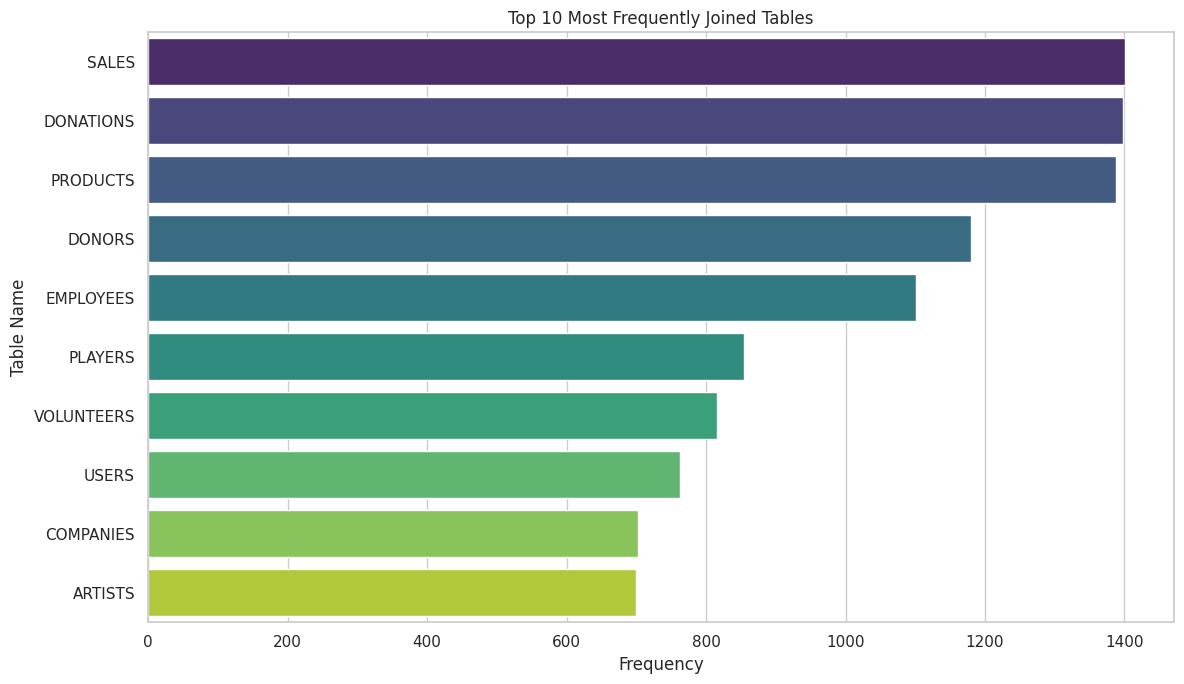

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visualization style
sns.set_theme(style="whitegrid")

# Plot the top 10 most frequently joined tables
plt.figure(figsize=(12, 7))
sns.barplot(data=table_counts_df.head(10), x='Frequency', y='Table', palette='viridis')
plt.title('Top 10 Most Frequently Joined Tables')
plt.xlabel('Frequency')
plt.ylabel('Table Name')
plt.tight_layout()
plt.show()


In [ ]:
sql_complexity_distribution = df['sql_complexity'].value_counts()
print("SQL Complexity Distribution:")
print(sql_complexity_distribution)

SQL Complexity Distribution:
sql_complexity
basic SQL           48466
aggregation         22015
single join         14932
subqueries           6719
window functions     3596
multiple_joins       2949
set operations       1050
CTEs                  273
Name: count, dtype: int64


### Infrastructure Provisioning

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
%%bash
# Source gcloud environment before running installation scripts
source /root/google-cloud-sdk/path.bash.inc
source /root/google-cloud-sdk/completion.bash.inc

cd $PROJECT_DIR/setup
#chmod +x install_gcp.sh
chmod +x install_kubectl.sh
#./install_gcp.sh
./install_kubectl.sh

# Ensure gcloud SDK bin directory is in PATH for this session
export PATH=$PATH:/root/google-cloud-sdk/bin

# Verify kubectl is now accessible and gke-gcloud-auth-plugin is functional
echo "Verifying kubectl accessibility and gke-gcloud-auth-plugin:"
kubectl version --client

kubectl is already installed.
Client Version: v1.35.2
Kustomize Version: v5.7.1
Verifying kubectl accessibility and gke-gcloud-auth-plugin:
Client Version: v1.35.2
Kustomize Version: v5.7.1


bash: line 2: /root/google-cloud-sdk/path.bash.inc: No such file or directory
bash: line 3: /root/google-cloud-sdk/completion.bash.inc: No such file or directory


In [ ]:
project_id = config_loader.get('project.id')
location = config_loader.get('project.region')
CLUSTER_NAME=config_loader.get("gke.cluster.name")
CLUSTER_NODE_COUNT=config_loader.get("gke.cluster.num_nodes")
CLUSTER_MACHINE_TYPE=config_loader.get("gke.cluster.machine_type")
WORKLOAD_POOL_FULL=f"{project_id}.svc.id.goog"
NODEPOOL_NAME=config_loader.get("gke.node_pool.name")
NODEPOOL_MACHINE_TYPE=config_loader.get("gke.node_pool.machine_type")
ACCELERATOR_TYPE=config_loader.get("gke.node_pool.accelerator.type")
ACCELERATOR_COUNT=config_loader.get("gke.node_pool.accelerator.count")
NODEPOOL_NUM_NODES=config_loader.get("gke.node_pool.num_nodes")
SCOPES=config_loader.get("gke.node_pool.scopes")
REPOSITORY_NAME=config_loader.get("gke.node_pool.repository_name")
GCP_SERVICE_ACCOUNT=config_loader.get("GCP_SERVICE_ACCOUNT")


# Ensure the script is executable
!chmod +x {project_dir}/setup/create_gke_cluster.sh

# Construct the command string and execute in a single bash shell
command_str = f"""
\"{project_dir}/setup/create_gke_cluster.sh\" \
  \"{CLUSTER_NAME}\" \
  \"{project_id}\" \
  \"{location}\" \
  \"{CLUSTER_MACHINE_TYPE}\" \
  \"{CLUSTER_NODE_COUNT}\" \
  \"{WORKLOAD_POOL_FULL}\" \
  \"{NODEPOOL_NAME}\" \
  \"{NODEPOOL_MACHINE_TYPE}\" \
  \"{ACCELERATOR_TYPE}\" \
  \"{ACCELERATOR_COUNT}\" \
  \"{NODEPOOL_NUM_NODES}\" \
  \"{SCOPES}\" \
  \"{REPOSITORY_NAME}\" \
  \"{GCP_SERVICE_ACCOUNT}\" \
"""
!bash -c "{command_str}"

In [ ]:
!gcloud components install gke-gcloud-auth-plugin --quiet

In [ ]:
# 1. Install the GKE auth plugin
!sudo apt-get install google-cloud-sdk-gke-gcloud-auth-plugin

!gcloud container clusters get-credentials sdk-training-cluster --region us-central1

In [ ]:
!kubectl create serviceaccount gemma-training-job-ksa

error: failed to create serviceaccount: Unauthorized


In [ ]:
!kubectl annotate serviceaccount default \
    iam.gke.io/gcp-service-account=${os.getenv('GCP_SERVICE_ACCOUNT')}

In [ ]:
# 1. Get the Access Token
token = !gcloud auth print-access-token
token = token[0]

# 2. Get Cluster Endpoint and CA Cert
endpoint = !gcloud container clusters describe {CLUSTER_NAME} --zone {location} --project {project_id} --format="value(endpoint)"
ca_cert = !gcloud container clusters describe {CLUSTER_NAME} --zone {location} --project {project_id} --format="value(masterAuth.clusterCaCertificate)"

endpoint = endpoint[0]
ca_cert = ca_cert[0]

# 3. Create a manual kubeconfig file
kubeconfig = f"""
apiVersion: v1
kind: Config
clusters:
- cluster:
    certificate-authority-data: {ca_cert}
    server: https://{endpoint}
  name: gke-cluster
contexts:
- context:
    cluster: gke-cluster
    user: colab-user
  name: gke-context
current-context: gke-context
users:
- name: colab-user
  user:
    token: {token}
"""

with open("kubeconfig.yaml", "w") as f:
    f.write(kubeconfig)

# 4. Set the environment variable for kubectl
os.environ['KUBECONFIG'] = '/content/kubeconfig.yaml'

print("Kubeconfig generated! Testing connection...")
!kubectl get nodes

Kubeconfig generated! Testing connection...
NAME                                                  STATUS   ROLES    AGE   VERSION
gke-sdk-training-cluster-default-pool-1cac64d0-6prm   Ready    <none>   24m   v1.34.3-gke.1444000
gke-sdk-training-cluster-default-pool-309e2884-fhbk   Ready    <none>   24m   v1.34.3-gke.1444000
gke-sdk-training-cluster-default-pool-92f7f7b4-j54q   Ready    <none>   24m   v1.34.3-gke.1444000


In [ ]:
HF_TOKEN = config_loader.get('hf_token')
project_id = config_loader.get('project.id')
gcs_bucket = config_loader.get('data.gcs_bucket')

# Fallback if gcs_bucket is not set in config
if gcs_bucket is None:
    print("Warning: 'data.gcs_bucket' not found in config. Defaulting to 'your-gcs-bucket-name'. Please update your config.yaml or set it manually.")
    gcs_bucket = "your-gcs-bucket-name" # Placeholder, user needs to replace this

print(f"GCS Bucket: {gcs_bucket}")

gcs_mount_path = f"/gcs/{gcs_bucket}"
repository_name = config_loader.get('gke.node_pool.repository_name')
ml_image_name = config_loader.get('gke.node_pool.ml_image_name')
ml_image_name='gemma_training'
ml_image_path = f"us-central1-docker.pkg.dev/{project_id}/{repository_name}/{ml_image_name}:latest"

os.environ['ML_IMAGE_PATH'] = ml_image_path
os.environ['ML_IMAGE_NAME'] = ml_image_name

In [ ]:
configmap_yaml_content = f"""apiVersion: v1
kind: ConfigMap
metadata:
  name: gemma-perf-config
data:
  GCP_PROJECT_ID_CM: "{project_id}"
  GCS_BUCKET_CM: "{gcs_bucket}"
  GCS_MOUNT_PATH: "{gcs_mount_path}"
"""

configmap_yaml_path = f"{project_dir}/job/gemma-perf-config.yaml"
with open(configmap_yaml_path, "w") as f:
    f.write(configmap_yaml_content)

print(f"Kubernetes ConfigMap YAML for gemma-perf-config created at: {configmap_yaml_path}")

Kubernetes ConfigMap YAML for gemma-perf-config created at: /content/aai-590-tinysql/job/gemma-perf-config.yaml


In [ ]:
script_template_path=f"{project_dir}/job/gemma_job_template.yaml"
script_template = ""
with open(script_template_path, "r") as f:
    script_template = f.read()

# Load the YAML template into a Python dictionary
base_job_script = yaml.safe_load(script_template)
# Correctly set the image field from the Python variable ml_image_path
base_job_script['spec']['template']['spec']['containers'][0]['image'] = ml_image_path


In [ ]:
command_str = "python3 src/model_training/gemma_vanilla_model_perf.py           --model_id 'google/gemma-3-4b-it'"

# Create a deep copy of base_job_script to ensure it remains immutable
perf_benchmark_job_dict = copy.deepcopy(base_job_script)

# Update the args in the appropriate location in the dictionary
perf_benchmark_job_dict['spec']['template']['spec']['containers'][0]['args'] = [command_str]

# --- FIX: Correctly set the GCS bucket in the volumeMounts ---
# Assuming the second volumeMount (index 1) is for gcs-fuse-csi
# And the gcs_bucket variable holds the correct bucket name (from config_loader.get('data.gcs_bucket'))
# This line ensures the actual bucket name is used instead of the literal placeholder '{gcs_bucket}'
perf_benchmark_job_dict['spec']['template']['spec']['containers'][0]['volumeMounts'][1]['mountPath'] = f"/gcs/{gcs_bucket}"


# Convert the dictionary back to a YAML string
perf_benchmark_job = yaml.dump(perf_benchmark_job_dict, sort_keys=False)


In [ ]:
gemma_vanilla_perf_yaml_path = f"{project_dir}/job/gemma-vanilla_perf.yaml"
with open(configmap_yaml_path, "w") as f:
    f.write(configmap_yaml_content)

In [ ]:
# Define the output directory and file path
output_dir = os.path.join(os.environ['PROJECT_DIR'], 'data')
train_output_file_path = os.path.join(output_dir, 'tinycode_train_ds.jsonl')
test_output_file_path = os.path.join(output_dir, 'tinycode_test_ds.jsonl')

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save the dataset to a JSON Lines file
#tinycode_train_ds.to_json(train_output_file_path)
#tinycode_test_ds.to_json(test_output_file_path)

print(f"Dataset saved to: {train_output_file_path}")
print(f"Dataset saved to: {test_output_file_path}")

Dataset saved to: /content/aai-590-tinysql/data/tinycode_train_ds.jsonl
Dataset saved to: /content/aai-590-tinysql/data/tinycode_test_ds.jsonl


In [ ]:
# Upload the local JSON Lines file to the GCS bucket
# The output_file_path and gcs_bucket variables are available from previous cells.
!gsutil cp {train_output_file_path} gs://{gcs_bucket}/data/tinycode_train_ds.jsonl
!gsutil cp {test_output_file_path} gs://{gcs_bucket}/data/tinycode_test_ds.jsonl

print(f"Dataset uploaded to gs://{gcs_bucket}/data/tinycode_train_ds.jsonl")

Copying file:///content/aai-590-tinysql/data/tinycode_train_ds.jsonl [Content-Type=application/octet-stream]...
- [1 files][ 58.9 MiB/ 58.9 MiB]                                                
Operation completed over 1 objects/58.9 MiB.                                     
Copying file:///content/aai-590-tinysql/data/tinycode_test_ds.jsonl [Content-Type=application/octet-stream]...
/ [1 files][  5.6 MiB/  5.6 MiB]                                                
Operation completed over 1 objects/5.6 MiB.                                      
Dataset uploaded to gs://cfpb-raw-lake-sdk/data/tinycode_train_ds.jsonl


In [ ]:
!kubectl get pods

No resources found in default namespace.


#### Image Creation

In [ ]:
%%bash
# Build and push the Docker image to Google Artifact Registry

# Ensure the script stops if any command fails
set -e

# Navigate to the project directory
cd $PROJECT_DIR

# Build the Docker image and tag it
echo "Building Docker image: " $ML_IMAGE_PATH
gcloud builds submit . --tag $ML_IMAGE_PATH

echo "Docker image build and push complete."

### Backup

In [ ]:
%%bash
zip -r /content/aai-590-tinysql.zip /content/aai-590-tinysql

echo "Zip file created at /content/aai-590-tinysql.zip"

  adding: content/aai-590-tinysql/ (stored 0%)
  adding: content/aai-590-tinysql/Dockerfile (deflated 36%)
  adding: content/aai-590-tinysql/setup/ (stored 0%)
  adding: content/aai-590-tinysql/setup/install_gcp.sh (deflated 56%)
  adding: content/aai-590-tinysql/setup/.ipynb_checkpoints/ (stored 0%)
  adding: content/aai-590-tinysql/setup/create_gke_cluster.sh (deflated 66%)
  adding: content/aai-590-tinysql/setup/install_kubectl.sh (deflated 50%)
  adding: content/aai-590-tinysql/env.txt (deflated 22%)
  adding: content/aai-590-tinysql/config/ (stored 0%)
  adding: content/aai-590-tinysql/config/config.yaml (deflated 54%)
  adding: content/aai-590-tinysql/config/.ipynb_checkpoints/ (stored 0%)
  adding: content/aai-590-tinysql/src/ (stored 0%)
  adding: content/aai-590-tinysql/src/model_training/ (stored 0%)
  adding: content/aai-590-tinysql/src/model_training/perf_testing.py (deflated 62%)
  adding: content/aai-590-tinysql/src/model_training/.ipynb_checkpoints/ (stored 0%)
  adding:

In [ ]:
from google.colab import files
files.download('/content/aai-590-tinysql.zip')

In [ ]:
gemma_vanilla_perf_yaml_path = f"{project_dir}/job/gemma-vanilla_perf.yaml"
with open(gemma_vanilla_perf_yaml_path, "w") as f:
    f.write(perf_benchmark_job)

print(f"Kubernetes job configuration saved to: {gemma_vanilla_perf_yaml_path}")


Kubernetes job configuration saved to: /content/aai-590-tinysql/job/gemma-vanilla_perf.yaml


In [ ]:
!kubectl apply -f {gemma_vanilla_perf_yaml_path}

job.batch/gemma-vanilla-perf-job created


In [ ]:
job_name = "gemma-vanilla-perf-job"
!kubectl delete job {job_name} --ignore-not-found=true


job.batch "gemma-vanilla-perf-job" deleted from default namespace


In [ ]:
!kubectl apply -f {gemma_vanilla_perf_yaml_path}

job.batch/gemma-vanilla-perf-job created


In [ ]:
job_name = "gemma-vanilla-perf-job"
!kubectl get pods -l job-name={job_name}

NAME                           READY   STATUS     RESTARTS   AGE
gemma-vanilla-perf-job-njlfn   0/2     Init:0/1   0          12s


In [ ]:
import time

job_name = "gemma-vanilla-perf-job"

# Get the pod name
pods_output = !kubectl get pods -l job-name={job_name} -o=jsonpath='{.items[0].metadata.name}'
pod_name = pods_output[0]

if not pod_name:
    print(f"No pod found for job {job_name}")
else:
    print(f"Found pod: {pod_name}")

    # Wait for the pod to be in Running state
    print(f"Waiting for pod {pod_name} to be in 'Running' status...")
    while True:
        status_output = !kubectl get pod {pod_name} -o=jsonpath='{.status.phase}'
        pod_status = status_output[0]
        print(f"Current status: {pod_status}")
        if pod_status == 'Running':
            print(f"Pod {pod_name} is now Running!")
            break
        elif pod_status in ['Pending', 'ContainerCreating', 'Init:0/1']:
            print(f"Pod {pod_name} is still {pod_status}. Waiting...")
            time.sleep(10) # Wait 10 seconds before checking again
        else:
            print(f"Pod {pod_name} entered an unexpected state: {pod_status}. Exiting.")
            break

    # Open an interactive shell session
    if pod_status == 'Running':
        print(f"Opening interactive shell session to {pod_name}...")
        !kubectl exec -it {pod_name} -- bash
    else:
        print("Cannot open shell: Pod is not in 'Running' state.")

Found pod: Error from server (BadRequest): Unable to find "/v1, Resource=pods" that match label selector "job-name={job_name}", field selector "": unable to parse requirement: values[0][job-name]: Invalid value: "{job_name}": a valid label must be an empty string or consist of alphanumeric characters, '-', '_' or '.', and must start and end with an alphanumeric character (e.g. 'MyValue',  or 'my_value',  or '12345', regex used for validation is '(([A-Za-z0-9][-A-Za-z0-9_.]*)?[A-Za-z0-9])?')
Waiting for pod Error from server (BadRequest): Unable to find "/v1, Resource=pods" that match label selector "job-name={job_name}", field selector "": unable to parse requirement: values[0][job-name]: Invalid value: "{job_name}": a valid label must be an empty string or consist of alphanumeric characters, '-', '_' or '.', and must start and end with an alphanumeric character (e.g. 'MyValue',  or 'my_value',  or '12345', regex used for validation is '(([A-Za-z0-9][-A-Za-z0-9_.]*)?[A-Za-z0-9])?') to 

In [ ]:
import time
import shlex # For proper shell quoting

job_name = "gemma-vanilla-perf-job"

# Construct the command string safely to get the pod name
# The jsonpath expression also needs to be correctly embedded and quoted for the shell
get_pod_name_cmd = f"kubectl get pods -l job-name={shlex.quote(job_name)} -o=jsonpath='{{.items[0].metadata.name}}'"
pods_output = !bash -c "{get_pod_name_cmd}"

# Assuming the output is a list, and the first element is the pod name
pod_name = pods_output[0].strip() if pods_output and pods_output[0].strip() else ""

if not pod_name:
    print(f"No pod found for job {job_name}. Command output: {pods_output}")
else:
    print(f"Found pod: {pod_name}")

    # Wait for the pod to be in Running state
    print(f"Waiting for pod {pod_name} to be in 'Running' status...")
    while True:
        # Construct the command string safely to get the pod status
        get_status_cmd = f"kubectl get pod {shlex.quote(pod_name)} -o=jsonpath='{{.status.phase}}'"
        status_output = !bash -c "{get_status_cmd}"

        if status_output and status_output[0].strip():
            pod_status = status_output[0].strip()
        else:
            pod_status = "Unknown" # Handle cases where output is empty or command fails

        print(f"Current status: {pod_status}")
        if pod_status == 'Running':
            print(f"Pod {pod_name} is now Running!")
            break
        elif pod_status in ['Pending', 'ContainerCreating', 'Init:0/1']:
            print(f"Pod {pod_name} is still {pod_status}. Waiting...")
            time.sleep(10) # Wait 10 seconds before checking again
        else:
            print(f"Pod {pod_name} entered an unexpected state: {pod_status}. Exiting.")
            break

    # Open an interactive shell session
    if pod_status == 'Running':
        print(f"Opening interactive shell session to {pod_name}...")
        # Construct the command string safely for kubectl exec
        exec_cmd = f"kubectl exec -it {shlex.quote(pod_name)} -- bash"
        !bash -c "{exec_cmd}"
    else:
        print("Cannot open shell: Pod is not in 'Running' state.")

Found pod: gemma-vanilla-perf-job-njlfn
Waiting for pod gemma-vanilla-perf-job-njlfn to be in 'Running' status...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Pod gemma-vanilla-perf-job-njlfn is still Pending. Waiting...
Current status: Pending
Po

In [ ]:
%%bash
export GCS_BUCKET=$(kubectl get configmap gemma-perf-config -o jsonpath='{.data.GCS_BUCKET_CM}')
envsubst < ${PROJECT_DIR}/job/gemma-vanilla_perf.yaml | kubectl apply -f -

### Performance Benchmarking for Plain Vanilla Gemma2-2b Model

In [ ]:
import pandas as pd
import io
output_path=f"/content/output/gemma2-benchmark-vanilla.csv"

df = pd.read_csv(output_path)

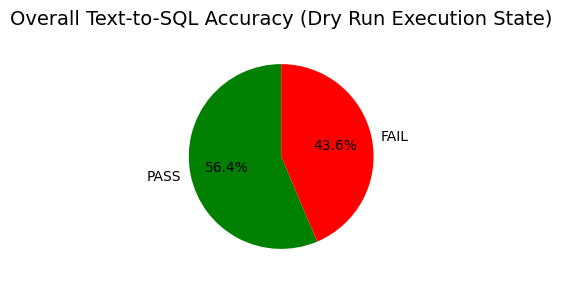

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute pass/fail counts
counts = df['DRY RUN Status'].value_counts()

plt.figure(figsize=(3, 3))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
plt.title('Overall Text-to-SQL Accuracy (Dry Run Execution State)', fontsize=14, pad=12)
plt.show()


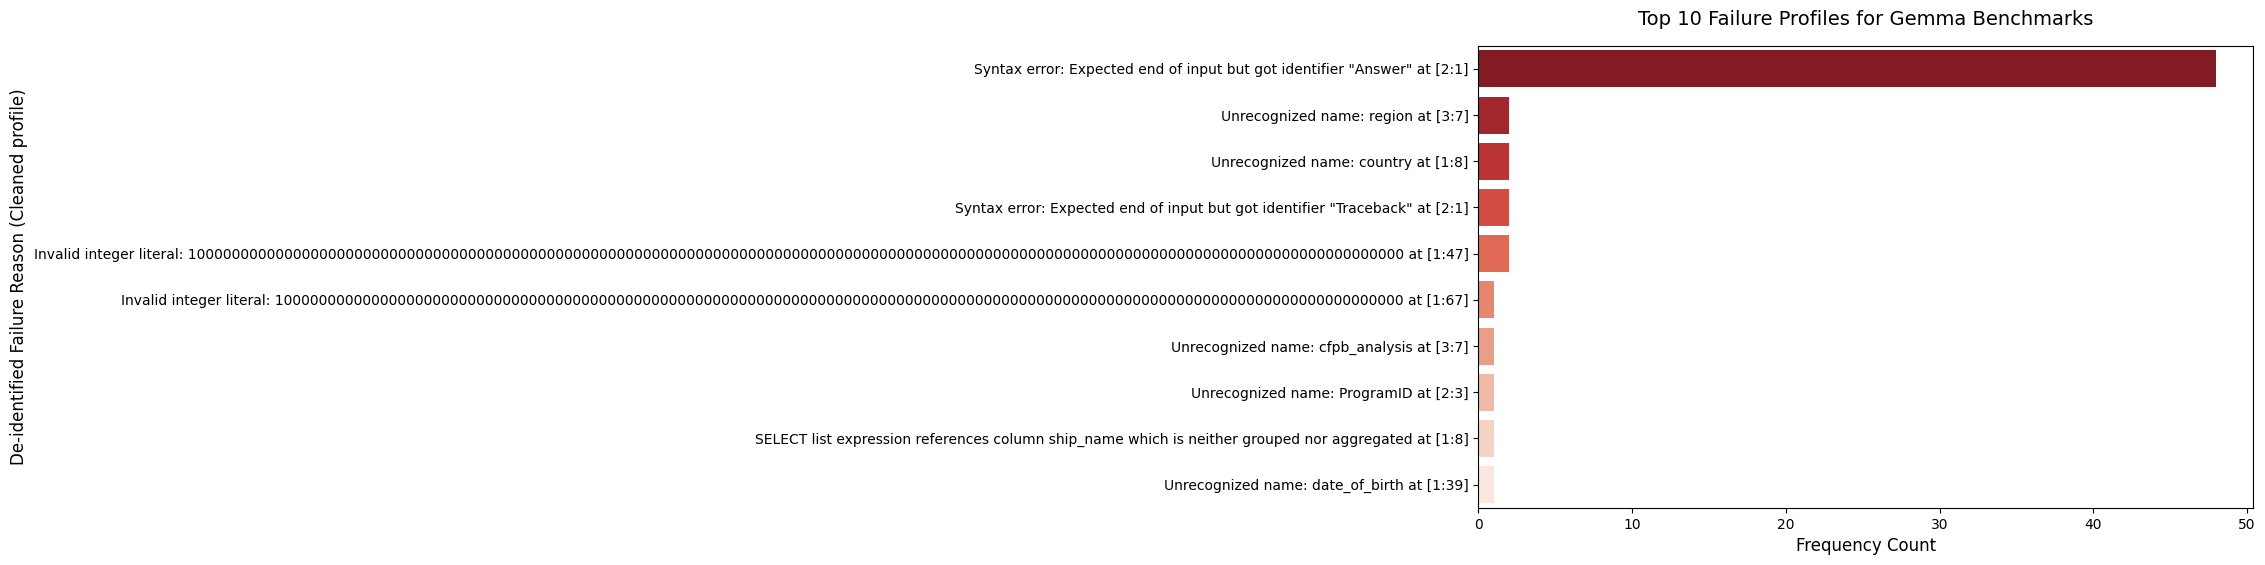

In [ ]:
# Isolate failures
failures = df[df['DRY RUN Status'] == 'FAIL']
reason_counts = failures['REASON'].value_counts()

plt.figure(figsize=(10, 6))
# Using a premium seaborn divergent palette for clarity
sns.barplot(x=reason_counts.values[:10], y=reason_counts.index[:10], palette="Reds_r")
plt.xlabel('Frequency Count', fontsize=12)
plt.ylabel('De-identified Failure Reason (Cleaned profile)', fontsize=12)
plt.title('Top 10 Failure Profiles for Gemma Benchmarks', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


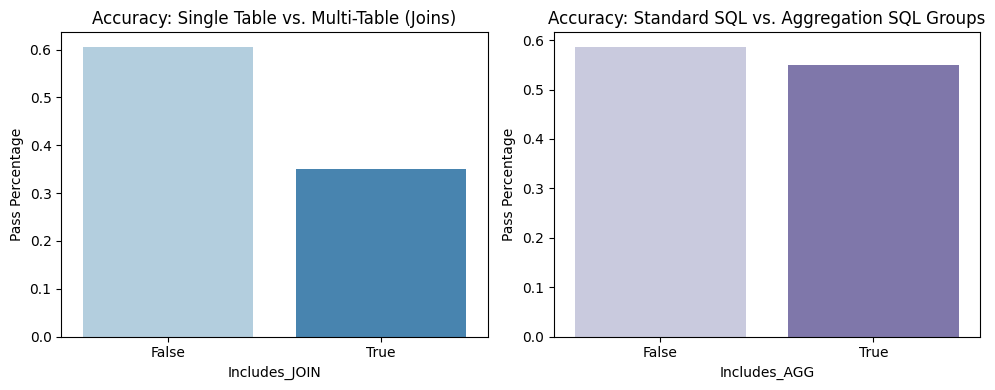

In [ ]:
# Feature engineering: Flag if the Gold SQL contains complex operations
df['Includes_JOIN'] = df['Gold SQL'].str.contains('JOIN', case=False, na=False)
df['Includes_AGG'] = df['Gold SQL'].str.contains('GROUP BY|SUM|MAX|AVG', case=True, na=False)

# Accuracy checks
join_acc = df.groupby('Includes_JOIN')['DRY RUN Status'].apply(lambda x: (x == 'PASS').mean())
agg_acc = df.groupby('Includes_AGG')['DRY RUN Status'].apply(lambda x: (x == 'PASS').mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Join complexity
sns.barplot(x=join_acc.index, y=join_acc.values, ax=axes[0], palette="Blues")
axes[0].set_title('Accuracy: Single Table vs. Multi-Table (Joins)')
axes[0].set_ylabel('Pass Percentage')

# Plot 2: Aggregations complexity
sns.barplot(x=agg_acc.index, y=agg_acc.values, ax=axes[1], palette="Purples")
axes[1].set_title('Accuracy: Standard SQL vs. Aggregation SQL Groups')
axes[1].set_ylabel('Pass Percentage')

plt.tight_layout()
plt.show()


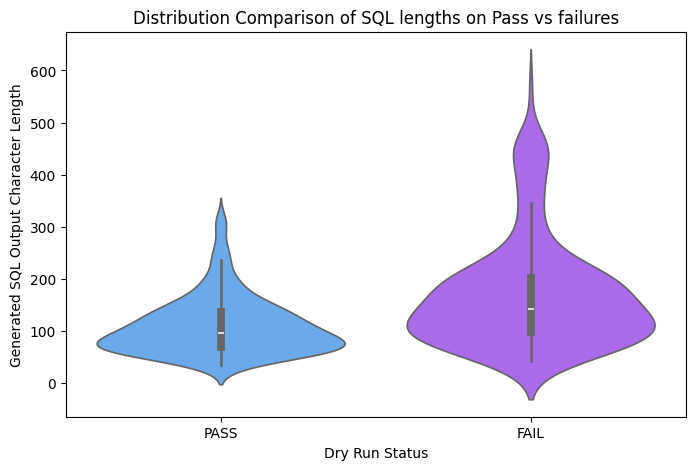

In [ ]:
df['sql_length'] = df['Gemma SQL'].apply(lambda x: len(str(x)))

plt.figure(figsize=(8, 5))
sns.violinplot(x='DRY RUN Status', y='sql_length', data=df, palette="cool")
plt.xlabel('Dry Run Status')
plt.ylabel('Generated SQL Output Character Length')
plt.title('Distribution Comparison of SQL lengths on Pass vs failures')
plt.show()


In [ ]:
!kubectl apply -f gemma-sft.yaml

In [ ]:
!tail -5 gemma-sft.log

{'loss': '0.3276', 'grad_norm': '0.1299', 'learning_rate': '9.238e-07', 'entropy': '0.3334', 'num_tokens': '6.984e+05', 'mean_token_accuracy': '0.9132', 'epoch': '0.128'}
{'loss': '0.325', 'grad_norm': '0.123', 'learning_rate': '2.537e-07', 'entropy': '0.3341', 'num_tokens': '7.131e+05', 'mean_token_accuracy': '0.9161', 'epoch': '0.1307'}
{'loss': '0.3128', 'grad_norm': '0.0957', 'learning_rate': '2.098e-09', 'entropy': '0.3336', 'num_tokens': '7.273e+05', 'mean_token_accuracy': '0.9185', 'epoch': '0.1333'}
{'eval_loss': '0.3289', 'eval_runtime': '92.79', 'eval_samples_per_second': '10.78', 'eval_steps_per_second': '1.347', 'eval_entropy': '0.3404', 'eval_num_tokens': '7.273e+05', 'eval_mean_token_accuracy': '0.915', 'epoch': '0.1333'}
{'train_runtime': '2621', 'train_samples_per_second': '1.526', 'train_steps_per_second': '0.191', 'train_loss': '0.3967', 'epoch': '0.1333'}


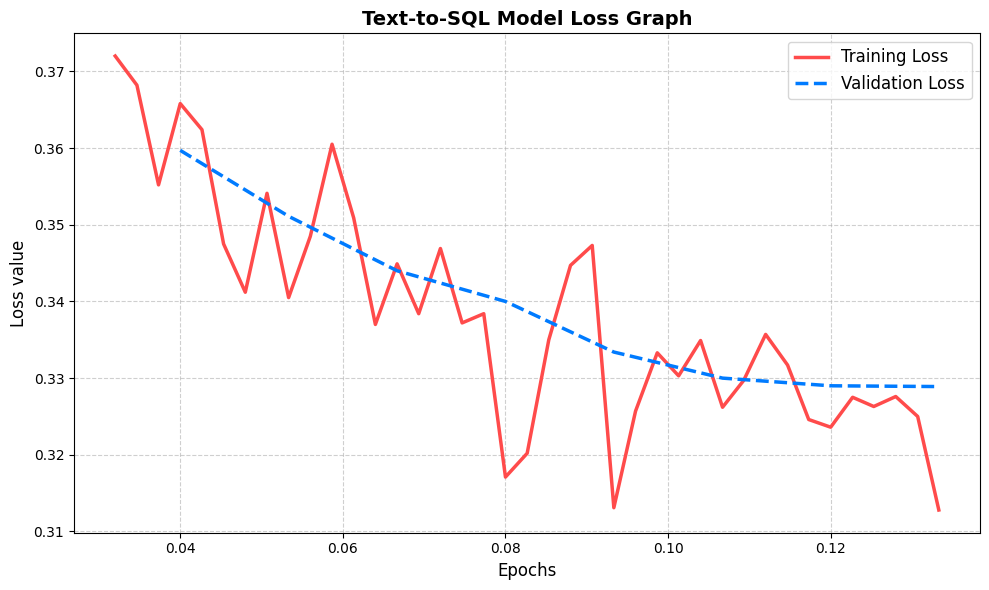

In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read and parse metrics
log_file_path = "gemma-sft.log"
train_metrics = []
eval_metrics = []

with open(log_file_path, "r") as f:
    for line in f:
        line = line.strip()
        if line.startswith("{"):
            try:
                # Safely parse string dictionaries
                metric_dict = ast.literal_eval(line)

                # Check for standard Training Loss
                if "loss" in metric_dict and "eval_loss" not in metric_dict:
                    train_metrics.append({
                        "epoch": float(metric_dict["epoch"]),
                        "train_loss": float(metric_dict["loss"])
                    })

                # Check for Validation/Evaluation Loss
                elif "eval_loss" in metric_dict:
                    eval_metrics.append({
                        "epoch": float(metric_dict["epoch"]),
                        "eval_loss": float(metric_dict["eval_loss"])
                    })
            except Exception:
                pass # Skip malformed or logging summary lines

# 2. Convert to separate DataFrames
df_train = pd.DataFrame(train_metrics)
df_eval = pd.DataFrame(eval_metrics)

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# --- Plot Training Loss ---
if not df_train.empty:
    plt.plot(df_train["epoch"], df_train["train_loss"], label="Training Loss", color="#FF4B4B", linewidth=2.5)

# --- Plot Validation Loss (if present) ---
if not df_eval.empty:
    plt.plot(df_eval["epoch"], df_eval["eval_loss"], label="Validation Loss", color="#007BFF", linestyle="--", linewidth=2.5)
else:
    print("⚠️  No 'eval_loss' found in your log file. To get validation checks, ensure you provide validation data to SFTTrainer in sft.py")

# Style choices
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss value", fontsize=12)
plt.title("Text-to-SQL Model Loss Graph", fontsize=14, fontweight='bold')
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)

# Display the graph
plt.tight_layout()
plt.show()


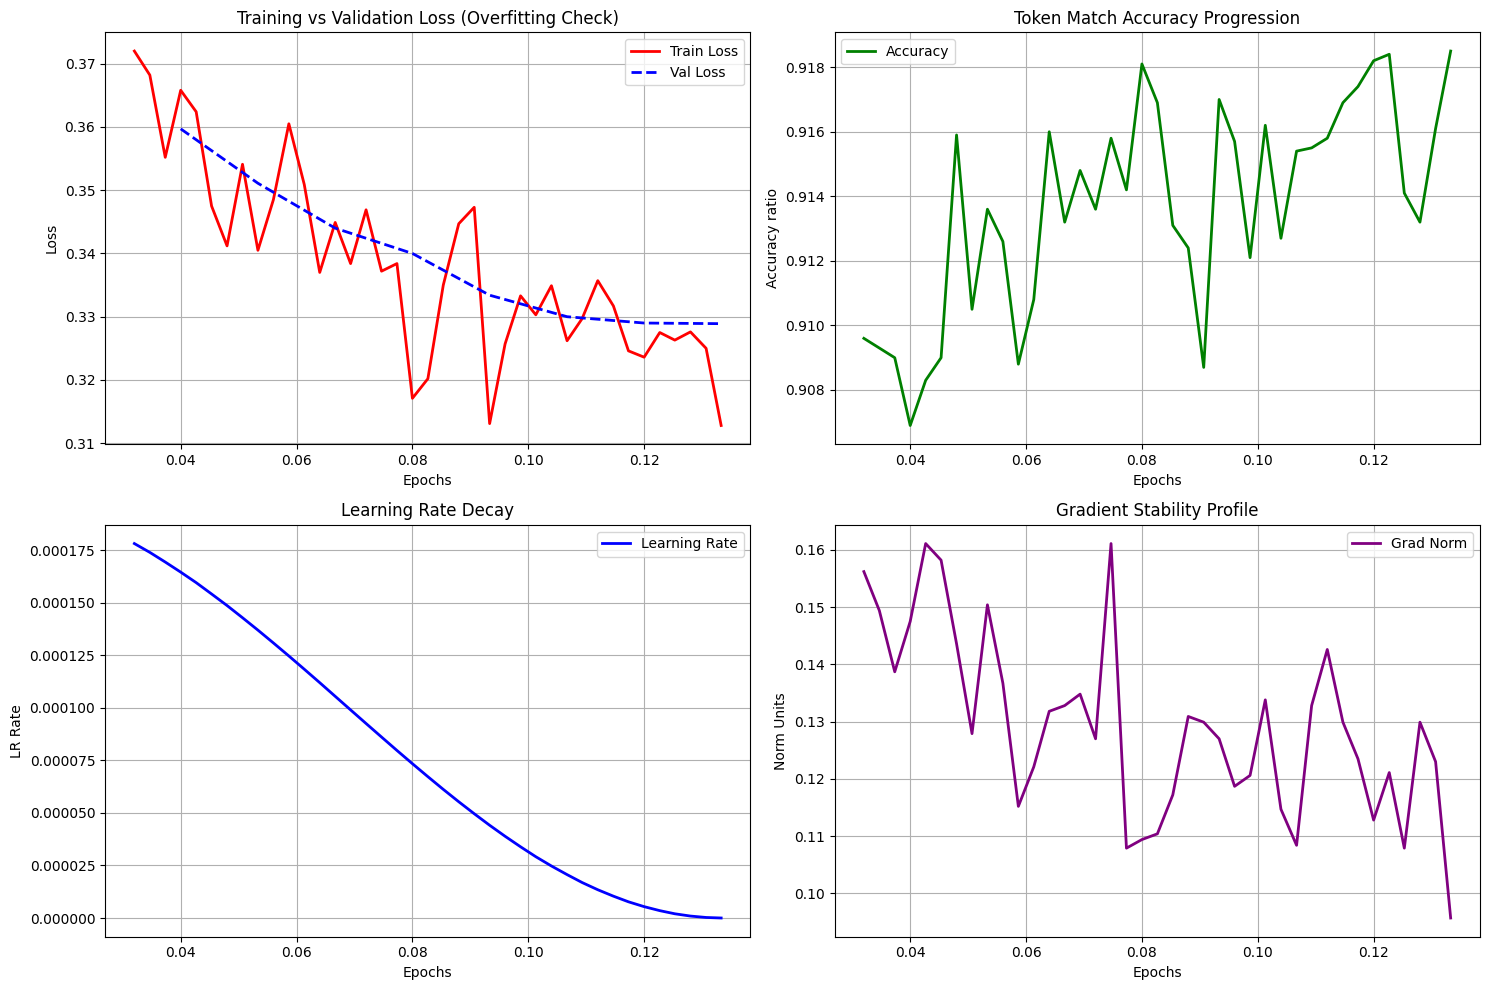

In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read and parse metrics
log_file_path = "gemma-sft.log"
train_metrics = []
eval_metrics = []

with open(log_file_path, "r") as f:
    for line in f:
        line = line.strip()
        if line.startswith("{"):
            try:
                d = ast.literal_eval(line)

                # Check for EVALUATION Loss
                if "eval_loss" in d:
                    eval_metrics.append({
                        "epoch": float(d["epoch"]),
                        "eval_loss": float(d["eval_loss"])
                    })

                # Check for TRAINING Loss
                elif "loss" in d:
                    train_metrics.append({
                        "epoch": float(d["epoch"]),
                        "loss": float(d["loss"]),
                        "lr": float(d.get("learning_rate", 0)),
                        "grad_norm": float(d.get("grad_norm", 0)),
                        "acc": float(d.get("mean_token_accuracy", 0))
                    })
            except Exception:
                pass

df_train = pd.DataFrame(train_metrics)
df_eval = pd.DataFrame(eval_metrics)

# 2. Plot 4-Panel Dashboard
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# --- Top Left: Compare Train Loss vs Validation Loss ---
if not df_train.empty:
    axs[0, 0].plot(df_train["epoch"], df_train["loss"], label="Train Loss", color='red', linewidth=2)
if not df_eval.empty:
    axs[0, 0].plot(df_eval["epoch"], df_eval["eval_loss"], label="Val Loss", color='blue', linestyle="--", linewidth=2)
axs[0, 0].set_xlabel("Epochs")
axs[0, 0].set_ylabel("Loss")
axs[0, 0].set_title("Training vs Validation Loss (Overfitting Check)")
axs[0, 0].grid(True)
axs[0, 0].legend()

# --- Top Right: Token Accuracy ---
if not df_train.empty:
    axs[0, 1].plot(df_train["epoch"], df_train["acc"], label="Accuracy", color='green', linewidth=2)
axs[0, 1].set_xlabel("Epochs")
axs[0, 1].set_ylabel("Accuracy ratio")
axs[0, 1].set_title("Token Match Accuracy Progression")
axs[0, 1].grid(True)
axs[0, 1].legend()

# --- Bottom Left: Learning Rate Schedule ---
if not df_train.empty:
    axs[1, 0].plot(df_train["epoch"], df_train["lr"], label="Learning Rate", color='blue', linewidth=2)
axs[1, 0].set_xlabel("Epochs")
axs[1, 0].set_ylabel("LR Rate")
axs[1, 0].set_title("Learning Rate Decay")
axs[1, 0].grid(True)
axs[1, 0].legend()

# --- Bottom Right: Gradient Norm (Stability) ---
if not df_train.empty:
    axs[1, 1].plot(df_train["epoch"], df_train["grad_norm"], label="Grad Norm", color='purple', linewidth=2)
axs[1, 1].set_xlabel("Epochs")
axs[1, 1].set_ylabel("Norm Units")
axs[1, 1].set_title("Gradient Stability Profile")
axs[1, 1].grid(True)
axs[1, 1].legend()

plt.tight_layout()
plt.show()


**Interpretations:**


**1. The Overfitting Check (Train Loss vs Validation Loss)**


**Actual Values:**

**Start (Step 150 approx):** Train Loss 0.372 vs. Val Loss 0.359
**Finish (Step 500):** Train Loss 0.312 vs. Val Loss 0.328
Both Training and Validation losses are decreasing smoothly together. Crucially, the Validation loss (0.328) is almost identical to the Training loss (0.312).

**Perfect Generalization.** If the model were overfitting, the Val Loss would have spiked upwards while Train Loss plummeted. Since it stayed flat alongside it, your model can generalize to unseen data!



**2. Validation Accuracy (Quality)**

**Actual Values:**
**Validation Token Accuracy:** 91.50%

When shown the 1,000 hidden validation samples, the model predicted the exact target token string with 91.5% accuracy!
For Text-to-SQL, accuracy above 90% indicates it has locked onto BigQuery syntax patterns (comma placements, capitalization, keyword usage).

** 3. Gradient Norm (Safety Checks)**

**Actual Values:** Stably hugging between 0.09 and 0.16 during the entire run.

Low and flat gradients mean the model was never "confused" or experiencing weird outliers. The learning rate of 2e-4 with cosine decay was soft and safe.


In [ ]:
import sys
import os

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

from utils import sql_utils

if "KUBERNETES_SERVICE_HOST" in os.environ:
    del os.environ["KUBERNETES_SERVICE_HOST"]
os.environ["GKE_DIAGON_IDENTIFIER"] = os.environ.get("HOSTNAME", "sft-pod-1")
os.environ["GKE_DIAGON_METADATA"] = ‘os.environ.get(“PROJECT_METADATA”)’


import torch
from datasets import load_dataset, load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from google_cloud_mldiagnostics import machinelearning_run, metrics, metric_types
from transformers import TrainerCallback

# --- CONFIGURATION ---
MODEL_ID = "google/gemma-2-2b"
DATASET_ID = os.environ.get(“DATASET_ID”)
OUTPUT_DIR = "./gemma-2-2b-sql-finetuned"
HUGGINGFACE_TOKEN = os.environ.get("HF_TOKEN") # Ensure your token is set for Gemma access


# --- 2. CREATE A HUGGING FACE CALLBACK ---
class GCPDiagnosticsCallback(TrainerCallback):
    """Pulls logs from SFTTrainer and pushes them to GCP ML Diagnostics"""
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            # The SDK uses metrics.record() with predefined MetricTypes
            if "loss" in logs:
                metrics.record(metric_types.MetricType.LOSS, logs["loss"], step=state.global_step)
            if "learning_rate" in logs:
                metrics.record(metric_types.MetricType.LEARNING_RATE, logs["learning_rate"], step=state.global_step)

# --- 1. DATA PROCESSING ---
print("Loading and formatting dataset...")

# Load the dataset you mentioned
dataset = load_dataset("gretelai/synthetic_text_to_sql")

def format_instruction(example):
    """
    Formats the data to match your exact inference prompt template.
    We append the target SQL to the end of the model turn.
    """
    prompt = example['sql_prompt']
    schema = sql_utils.extract_and_fix_ddl(example['sql_context'])  # Fix DDL
    target_sql = sql_utils.transpile_to_bigquery(example['sql'])     # Fix Query to BQ
    target_sql = sql_utils.prefix_table_names(target_sql, "{DATASET_ID}") # Lit prefix

    # Notice this exactly mirrors your generate_sql() structure
    text = f"""<start_of_turn>user
You are a GoogleSQL expert. Generate a BigQuery query to answer the question using the schema below.
Rules:
1. Use ONLY the table and columns provided in the schema.
2. Prefix all table names with `{DATASET_ID}.`.
3. Return ONLY the SQL query.

Schema:
{schema}

Question:
{prompt}<end_of_turn>
<start_of_turn>model
SQL:{target_sql}<end_of_turn>"""

    return {"text": text}

# Apply formatting and shuffle
# For this example, we take a subset to test the pipeline quickly. Remove the select() for a full run.
PROCESSED_DATA_CACHE_DIR = os.environ.get(“CACHE_DIR”)

if os.path.exists(PROCESSED_DATA_CACHE_DIR):
    print(f"Loading preprocessed dataset splits from cache: {PROCESSED_DATA_CACHE_DIR}")
    dataset_splits = load_from_disk(PROCESSED_DATA_CACHE_DIR)
    train_dataset = dataset_splits["train"]
    val_dataset = dataset_splits["test"]
else:
    print("No cache found. Preprocessing and transpiling records...")
    split_dataset = dataset["train"].train_test_split(test_size=1000, seed=42)
    train_subset = split_dataset["train"].shuffle(seed=42).select(range(20000))
    val_subset = split_dataset["test"]

    train_dataset = train_subset.map(format_instruction)
    val_dataset = val_subset.map(format_instruction)

    from datasets import DatasetDict
    dataset_splits = DatasetDict({"train": train_dataset, "test": val_dataset})

    print(f"Saving preprocessed dataset splits to cache: {PROCESSED_DATA_CACHE_DIR}")
    dataset_splits.save_to_disk(PROCESSED_DATA_CACHE_DIR)

# --- 2. MODEL & TOKENIZER SETUP (QLoRA) ---
print(f"Loading {MODEL_ID} in 4-bit...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HUGGINGFACE_TOKEN)
tokenizer.padding_side = 'right' # Recommended for Gemma

# 4-bit Quantization Config to save memory
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    token=HUGGINGFACE_TOKEN
)

model = prepare_model_for_kbit_training(model)

# --- 3. LORA CONFIGURATION ---
# We target the attention modules for adaptation
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    optim="paged_adamw_32bit",
    save_steps=200,
    logging_steps=10,
    learning_rate=2e-4,
    fp16=False,
    bf16=True,
    max_grad_norm=0.3,
    #max_steps=500,
    num_train_epochs=1,
    eval_strategy="steps",
    eval_steps=200,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",

    max_length=1024,
    dataset_text_field="text",
)


# --- 3. INJECT INTO SFTTRAINER ---
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=training_args,
    processing_class=tokenizer
)

# --- 4. EXECUTE TRAINING ---
print("Starting training...")

trainer.train()

# --- 7. SAVE ADAPTERS ---
print(f"Saving fine-tuned model adapters to {OUTPUT_DIR}...")
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Done!")


In [ ]:
import sys
import os

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

from utils import sql_utils
import json
import os
import torch
import re
try:
    import sqlglot
    from sqlglot import exp
    SQLGLOT_AVAILABLE = True
except ImportError:
    SQLGLOT_AVAILABLE = False
from google.cloud import bigquery
from google.api_core.exceptions import Conflict
from transformers import AutoTokenizer, AutoModelForCausalLM

# --- CONFIGURATION ---
file_path = os.environ.get(“FILE_PATH”)
output_log_path = os.environ.get(“OUTPUT_LOG_PATH”)
PROJECT_ID = os.environ.get(“PROJECT_ID”)
DATASET_ID = os.environ.get(“DATASET_ID”)
FULL_DATASET_PATH = f"{PROJECT_ID}.{DATASET_ID}"
LOCATION = os.environ.get(“LOCATION”)
MODEL_ID = "google/gemma-2-2b"

# Initialize BigQuery Client
client = bigquery.Client(project=PROJECT_ID, location=LOCATION)

# --- MODEL LOADING ---
print(f"Loading model {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

def setup_bigquery_environment():
    dataset = bigquery.Dataset(FULL_DATASET_PATH)
    dataset.location = LOCATION
    try:
        client.create_dataset(dataset, timeout=30)
    except Conflict:
        pass

def extract_sql_only(text):
    """
    Cleans model chatter and extracts the actual SQL statement.
    Fixed: No longer splits on 'table' or 'schema' which are valid SQL keywords.
    """

    #print (f"Raw Generated SQL : {text}")

    # Remove the trigger prefix if model repeats it
    text = re.sub(r'^(Answer:|SQL:|\s+)', '', text, flags=re.IGNORECASE).strip()

    # Extract everything until the first semicolon
    if ';' in text:
        text = text.split(';')[0].strip() + ';'

    # Remove common hallucinated trailing text
    text = re.split(r'(?i)answer:|note:|explanation:|---|\n\n', text)[0].strip()

    # Final cleanup of non-ASCII garbage
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    return text

def validate_sql_dry_run(sql_query):
    """Validates the generated SQL via BigQuery Dry Run."""
    if not sql_query or not any(k in sql_query.upper() for k in ["SELECT", "DELETE", "UPDATE", "INSERT", "WITH"]):
        return False, "Malformed or Empty SQL"

    job_config = bigquery.QueryJobConfig(dry_run=True, default_dataset=FULL_DATASET_PATH)
    try:
        client.query(sql_query, job_config=job_config)
        return True, "Success"
    except Exception as e:
        error_msg = str(e)
        # Strip BigQuery URL
        error_msg = re.sub(r"400 POST https://bigquery\.googleapis\.com/bigquery/v2/projects/[^/]+/jobs\?prettyPrint=false:?", "", error_msg, flags=re.IGNORECASE).strip()
        # Strip Job ID
        error_msg = re.sub(r"Job ID:\s*[a-f0-9\-]+", "", error_msg, flags=re.IGNORECASE)
        # Strip Location
        error_msg = re.sub(r"Location:\s*[a-z0-9\-]+", "", error_msg, flags=re.IGNORECASE)
        # Clean double spaces and leading characters
        error_msg = re.sub(r"\s+", " ", error_msg).strip()
        error_msg = re.sub(r"^:\s*", "", error_msg)
        return False, error_msg

def extract_and_fix_ddl(context_raw):
    """Transpiles MySQL DDL to BigQuery and strips constraints."""
    return sql_utils.extract_and_fix_ddl(context_raw)

def generate_sql(prompt, schema):
    """Generates SQL with hard-coded dataset anchoring and a code trigger."""
    input_text = f"""<start_of_turn>user
You are a GoogleSQL expert. Generate a BigQuery query to answer the question using the schema below.
Rules:
1. Use ONLY columns provided in the schema. If a column is not explicitly defined in the CREATE TABLE statement, you MUST NOT use it. Do not assume standard names exist.
2. Prefix all table names with `{DATASET_ID}.`.
3. Return ONLY the SQL query.

Schema:
{schema}

Question:
{prompt}<end_of_turn>
<start_of_turn>model
SQL:""" # Triggering the start of the code block

    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False,        # Use greedy decoding to minimize randomness
            #repetition_penalty=1.2, # Discourage repeating the prompt
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True).strip()
    return extract_sql_only(decoded)

def process_records(path, count=500):
    if not os.path.exists(path):
        print(f"Path {path} not found.")
        return

    setup_bigquery_environment()
    results_to_save = []

    print(f"Benchmarking {count} records...")

    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= count: break
            record = json.loads(line)

            sql_prompt = record.get("sql_prompt", "")
            gold_sql = record.get("sql", "")
            final_ddl = extract_and_fix_ddl(record.get("sql_context", ""))

            # 1. Execute DDL so the table exists for validation
            job_config = bigquery.QueryJobConfig(default_dataset=FULL_DATASET_PATH)
            table_exists = False
            if final_ddl:
                try:
                    client.query(final_ddl, job_config=job_config).result()
                    table_exists = True
                except Exception as e:
                    print(f"DDL Setup Error Record {i+1}: {e}")

            # 2. Generate and Validate SQL
            if table_exists:
                gen_sql = generate_sql(sql_prompt, final_ddl)

                # Attempt to transpile from MySQL to BigQuery (fallback for MySQL-generated syntax)
                try:
                    gen_sql = sql_utils.transpile_to_bigquery(gen_sql)
                except Exception:
                    # Fallback to original if transpilation fails
                    pass

                # Swap literal placeholder for actual BigQuery dataset before validation
                run_sql = gen_sql.replace("{DATASET_ID}", DATASET_ID)
                is_valid, bq_msg = validate_sql_dry_run(run_sql)

                res = {
                    "prompt": sql_prompt,
                    "original_sql": gold_sql,
                    "generated_sql": gen_sql,
                    "valid": is_valid,
                    #"error": bq_msg if not is_valid else None
                }
                results_to_save.append(res)

                print(f"--- Record {i+1} ---")
                print(f"Q: {sql_prompt}")
                print(f"Gold SQL : {gold_sql}")
                print(f"GEMMA SQL: {gen_sql}")
                print(f"DRY RUN: {'PASS' if is_valid else 'FAIL'}")
                if not is_valid: print(f"REASON: {bq_msg}")
                print("-" * 30)
            else:
                print(f"Skipping Record {i+1} due to missing schema context.")

    with open(output_log_path, 'w') as out_f:
        for entry in results_to_save:
            out_f.write(json.dumps(entry) + '\n')

if __name__ == "__main__":
    process_records(file_path)


In [ ]:
import re

try:
    import sqlglot
    from sqlglot import exp
    SQLGLOT_AVAILABLE = True
except ImportError:
    SQLGLOT_AVAILABLE = False

def extract_and_fix_ddl(context_raw):
    """Transpiles MySQL DDL to BigQuery and strips constraints."""
    if not SQLGLOT_AVAILABLE:
        return "" # Skip or keep if not available

    try:
        statements = sqlglot.parse(context_raw, read="mysql")
    except Exception:
        return ""

    ddl_statements = []
    for expression in statements:
        if isinstance(expression, exp.Create) and expression.args.get("kind") == "TABLE":
            expression.set("exists", True)

            if isinstance(expression.this, exp.Schema):
                table_ident = expression.this.this
            else:
                table_ident = expression.this
            if isinstance(table_ident, exp.Table):
                table_ident.set("db", None)
                table_ident.set("catalog", None)

            schema = expression.this
            if isinstance(schema, exp.Schema):
                for column_def in schema.expressions:
                    if isinstance(column_def, exp.ColumnDef):
                        column_def.set("constraints", [
                            c for c in column_def.args.get("constraints", [])
                            if not (isinstance(c.kind, (exp.PrimaryKeyColumnConstraint, exp.Reference)) or "FOREIGN" in str(c.kind).upper())
                        ])
                schema.set("expressions", [
                    e for e in schema.expressions
                    if not (isinstance(e, exp.Constraint) and any(isinstance(k, (exp.PrimaryKey, exp.ForeignKey, exp.Reference)) for k in e.args.values()))
                ])
            ddl_statements.append(expression.sql(dialect="bigquery"))
    return ";\n".join(ddl_statements)

def transpile_to_bigquery(sql_query):
    """Fallback to transpile query from MySQL to BigQuery (handling syntax bias)."""
    if not SQLGLOT_AVAILABLE:
        return sql_query

    try:
        transpiled_list = sqlglot.transpile(sql_query, read="mysql", write="bigquery")
        if isinstance(transpiled_list, list) and transpiled_list and transpiled_list[0] != sql_query:
            return transpiled_list[0]
    except Exception:
        pass
    return sql_query


def prefix_table_names(sql_query, prefix_string):
    """Parses query and prefixes all real table names with prefix_string (e.g. {DATASET_ID})."""
    if not SQLGLOT_AVAILABLE:
        return sql_query
    try:
        expression = sqlglot.parse_one(sql_query, read="mysql")
        cte_names = {cte.alias for cte in expression.find_all(exp.CTE)} if hasattr(expression, "find_all") else set()

        for table in expression.find_all(exp.Table):
            if table.name in cte_names:
                continue # Skip CTEs
            if not table.args.get("db"):
                table.set("db", prefix_string)
        return expression.sql(dialect="bigquery")
    except Exception:
        return sql_query


### Inference with SFT Model

In [ ]:

!gcloud storage cp {train_output_file_path} gs://{gcs_bucket}/data/tinycode_train_ds.jsonl
!gcloud storage cp {test_output_file_path} gs://{gcs_bucket}/data/tinycode_test_ds.jsonl

In [ ]:
!tail sft_inference_output.json

  "dry_run_valid": false,
  "failure_reason": "Unrecognized name: category at [1:8]"
}
{
  "record_index": 200,
  "prompt": "What are the names and locations of all factories with a workforce diversity score above 85?",
  "generated_sql": "SELECT name, location FROM {DATASET_ID}.factories WHERE diversity_score > 85",
  "dry_run_valid": false,
  "failure_reason": "Unrecognized name: diversity_score at [1:83]"
}

In [ ]:
import pandas as pd
import json
df = pd.read_json("./sft_inference_output.jsonl", lines=True)

test_df = pd.read_json("./data/data_tinycode_test_ds.jsonl", lines=True)

#df1.value_counts()

merged_df = pd.merge(test_df, df, left_on="sql_prompt", right_on="prompt", how="inner")

In [ ]:
import numpy as np
import pandas as pd

# Assuming merged_pdf is your DataFrame
merged_pdf = merged_df
# Define conditions for categorization
conditions = [
    merged_pdf["failure_reason"].str.contains(
        "not found|Unrecognized name", case=False, na=False
    ),
    merged_pdf["failure_reason"].str.contains(
        "neither grouped nor aggregated", case=False, na=False
    ),
    merged_pdf["failure_reason"].str.contains(
        "Function not found", case=False, na=False
    ),
    merged_pdf["failure_reason"].str.contains(
        "Syntax error", case=False, na=False
    ),
    merged_pdf["failure_reason"].str.contains(
        "404 POST|Not found: Table|Not found: Dataset", case=False, na=False
    ),
]

# Define choices corresponding to conditions
choices = [
    "Unrecognized Name / Column Not Found",
    "Invalid GROUP BY / Aggregation Error",
    "Unsupported Function",
    "Syntax Error",
    "Missing Table or Dataset",
]

# Create a new column 'failure_category'
merged_pdf["failure_category"] = np.select(
    conditions, choices, default="Other / Unknown"
)



In [ ]:
merged_pdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          201 non-null    int64 
 1   domain                      201 non-null    object
 2   domain_description          201 non-null    object
 3   sql_complexity              201 non-null    object
 4   sql_complexity_description  201 non-null    object
 5   sql_task_type               201 non-null    object
 6   sql_task_type_description   201 non-null    object
 7   sql_prompt                  201 non-null    object
 8   sql_context                 201 non-null    object
 9   sql                         201 non-null    object
 10  sql_explanation             201 non-null    object
 11  record_index                201 non-null    int64 
 12  prompt                      201 non-null    object
 13  generated_sql               201 non-null    object

In [ ]:
merged_pdf["dry_run_valid"].value_counts()

dry_run_valid
True     129
False     52
Name: count, dtype: int64

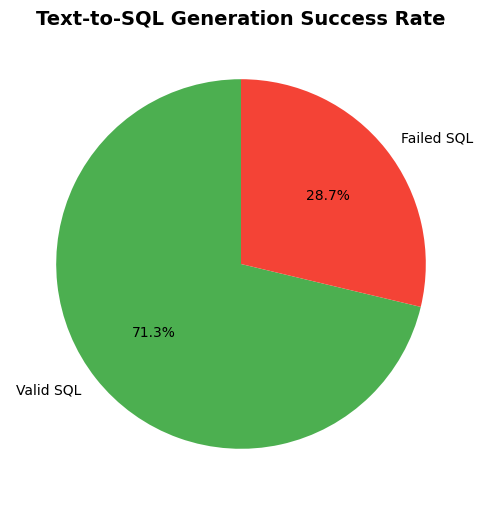

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# Count valid vs invalid
success_counts = merged_pdf["dry_run_valid"].value_counts()

# Plot pie chart safely
success_counts.plot.pie(
    autopct="%1.1f%%",
    # Dynamically map the labels based on what categories are present
    labels=success_counts.index.map({True: "Valid SQL", False: "Failed SQL"}),
    colors=["#4CAF50", "#F44336"][
        : len(success_counts)
    ],  # Safe slice for colors
    startangle=90,
)

plt.title("Text-to-SQL Generation Success Rate", fontsize=14, fontweight="bold")
plt.ylabel("")  # Remove y-label
plt.show()


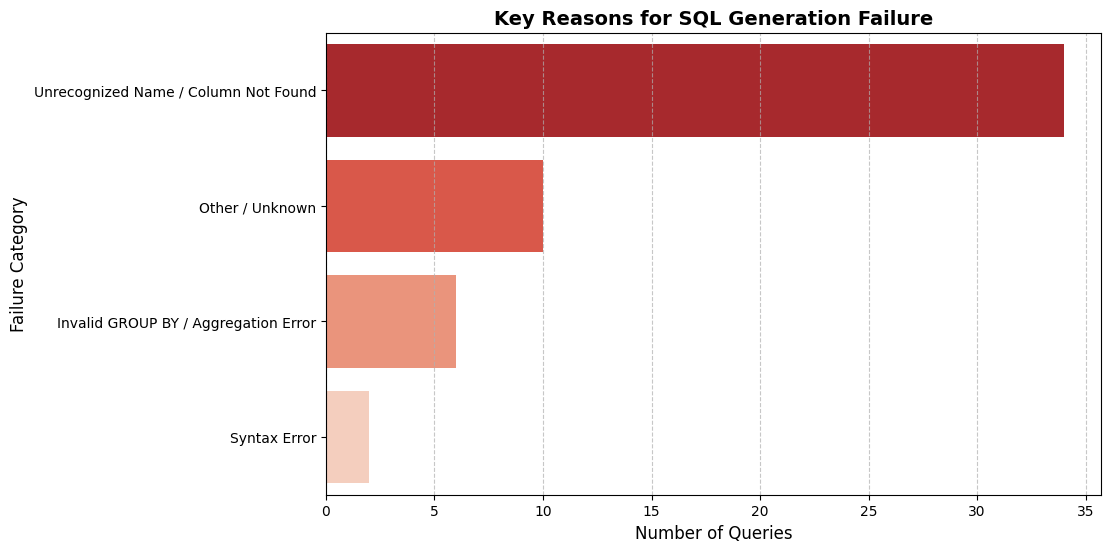

In [ ]:
# Filter for failed records only
failed_df = merged_pdf[merged_pdf["dry_run_valid"] == False]

if "failure_category" in failed_df.columns:
    plt.figure(figsize=(10, 6))

    # Plot counts of each failure category
    sns.countplot(
        y="failure_category",
        data=failed_df,
        order=failed_df["failure_category"].value_counts().index,
        palette="Reds_r",
    )

    plt.title(
        "Key Reasons for SQL Generation Failure", fontsize=14, fontweight="bold"
    )
    plt.xlabel("Number of Queries", fontsize=12)
    plt.ylabel("Failure Category", fontsize=12)
    plt.grid(axis="x", linestyle="--", alpha=0.7)

    plt.show()
else:
    print(
        "Please run the categorization code snippet provided earlier to create the 'failure_category' column first."
    )


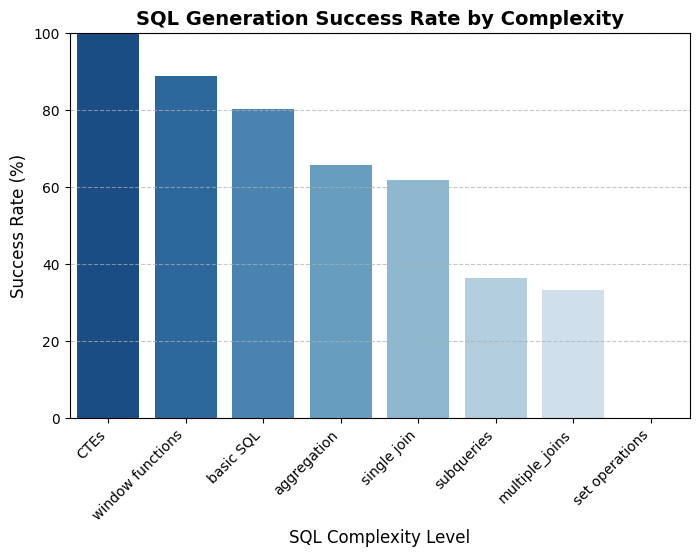

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# Calculate success rate percentage per complexity level
complexity_perf = (
    merged_pdf.groupby("sql_complexity")["dry_run_valid"]
    .mean()
    .reset_index()
)
complexity_perf["success_rate"] = complexity_perf["dry_run_valid"] * 100

# Plot
sns.barplot(
    x="sql_complexity",
    y="success_rate",
    data=complexity_perf.sort_values("success_rate", ascending=False),
    palette="Blues_r",
)

plt.title(
    "SQL Generation Success Rate by Complexity", fontsize=14, fontweight="bold"
)
plt.xlabel("SQL Complexity Level", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Success Rate (%)", fontsize=12)
plt.ylim(0, 100)  # Keep scale consistent
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()
